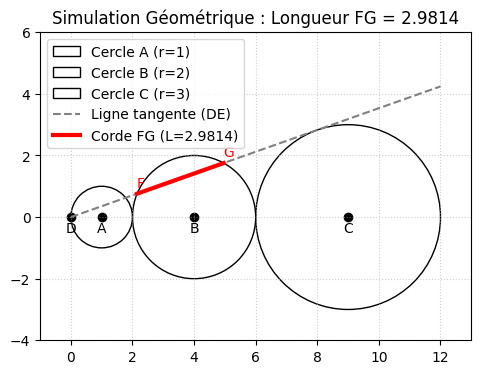

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Configuration du graphique
fig, ax = plt.subplots(figsize=(10, 4))
ax.set_aspect('equal')

# 1. Définition des centres et rayons
# On suppose une tangence externe parfaite entre les cercles pour que les points soient colinéaires.
# On place le point D à l'origine (0,0) pour simplifier, en supposant que D est sur le cercle A (comme sur l'image).
r_A, r_B, r_C = 1, 2, 3

# Coordonnées des centres sur l'axe X
# D est à x=0.
# Le cercle A (r=1) a son centre à x=1 pour que son bord gauche touche D.
c_A = (1, 0)
# Le cercle B (r=2) touche A. Distance centre A -> centre B = 1 + 2 = 3.
c_B = (1 + 1 + 2, 0) # x = 4
# Le cercle C (r=3) touche B. Distance centre B -> centre C = 2 + 3 = 5.
c_C = (4 + 2 + 3, 0) # x = 9

# 2. Calcul de la ligne tangente
# La ligne passe par D(0,0) et est tangente au cercle C(9, 0).
# Soit alpha l'angle de la ligne. Dans le triangle rectangle formé par le centre C, le point de tangence E, et D:
# sin(alpha) = côté_opposé / hypoténuse = rayon_C / distance_DC
dist_DC = 9
sin_alpha = r_C / dist_DC # 3/9 = 1/3
alpha = np.arcsin(sin_alpha)

# Coordonnées de la ligne pour l'affichage (y = x * tan(alpha))
x_line = np.linspace(0, 12, 100)
y_line = x_line * np.tan(alpha)

# 3. Calcul de la corde FG sur le cercle B
# Distance du centre B à la ligne (projection orthogonale)
dist_DB = c_B[0] # distance de D à B = 4
dist_B_line = dist_DB * np.sin(alpha) # d = 4 * 1/3 = 4/3

# Longueur de la corde FG = 2 * sqrt(R² - d²)
half_chord = np.sqrt(r_B**2 - dist_B_line**2)
chord_length = 2 * half_chord

# Points F et G (intersection visuelle approximative pour le tracé)
# On calcule les points exacts pour le tracé rouge
# Le centre de la corde sur la ligne est à la distance projection_D_B sur la ligne
proj_dist = dist_DB * np.cos(alpha)
# Coordonnées du milieu de la corde
M_chord = (proj_dist * np.cos(alpha), proj_dist * np.sin(alpha))
# Vecteur directeur de la ligne (u)
u = (np.cos(alpha), np.sin(alpha))
# Points F et G sont à +/- half_chord du milieu le long de la ligne
F = (M_chord[0] - half_chord * u[0], M_chord[1] - half_chord * u[1])
G = (M_chord[0] + half_chord * u[0], M_chord[1] + half_chord * u[1])

# 4. Tracé des éléments
# Cercles
circle_A = plt.Circle(c_A, r_A, fill=False, color='black', label='Cercle A (r=1)')
circle_B = plt.Circle(c_B, r_B, fill=False, color='black', label='Cercle B (r=2)')
circle_C = plt.Circle(c_C, r_C, fill=False, color='black', label='Cercle C (r=3)')

ax.add_patch(circle_A)
ax.add_patch(circle_B)
ax.add_patch(circle_C)

# Ligne tangente
ax.plot(x_line, y_line, color='grey', linestyle='--', label='Ligne tangente (DE)')

# Corde FG en rouge
ax.plot([F[0], G[0]], [F[1], G[1]], color='red', linewidth=3, label=f'Corde FG (L={chord_length:.4f})')

# Points clés
ax.scatter([0, 1, 4, 9], [0, 0, 0, 0], color='black') # D, A, B, C sur l'axe
ax.text(0, -0.5, 'D', ha='center')
ax.text(1, -0.5, 'A', ha='center')
ax.text(4, -0.5, 'B', ha='center')
ax.text(9, -0.5, 'C', ha='center')
ax.text(F[0], F[1]+0.2, 'F', color='red')
ax.text(G[0], G[1]+0.2, 'G', color='red')

# Mise en forme
ax.set_xlim(-1, 13)
ax.set_ylim(-4, 6)
ax.set_title(f"Simulation Géométrique : Longueur FG = {chord_length:.4f}")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()